In [1]:
import pandas as pd

data = {
    "Income":[25000,30000,45000,50000,60000,70000,80000,90000,100000,120000],
    "CreditScore":[550,600,620,650,700,720,750,780,800,850],
    "Age":[22,25,28,30,35,40,42,45,50,55],
    "LoanApproved":[0,0,0,0,1,1,1,1,1,1]
}

dataset = pd.DataFrame(data)
print(dataset)

   Income  CreditScore  Age  LoanApproved
0   25000          550   22             0
1   30000          600   25             0
2   45000          620   28             0
3   50000          650   30             0
4   60000          700   35             1
5   70000          720   40             1
6   80000          750   42             1
7   90000          780   45             1
8  100000          800   50             1
9  120000          850   55             1


In [2]:
dataset.shape
dataset.columns
dataset.info()
dataset.describe()
dataset.isnull().sum()
dataset.duplicated().sum()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Income        10 non-null     int64
 1   CreditScore   10 non-null     int64
 2   Age           10 non-null     int64
 3   LoanApproved  10 non-null     int64
dtypes: int64(4)
memory usage: 452.0 bytes


np.int64(0)

In [4]:
dataset["LoanApproved"].value_counts()

LoanApproved
1    6
0    4
Name: count, dtype: int64

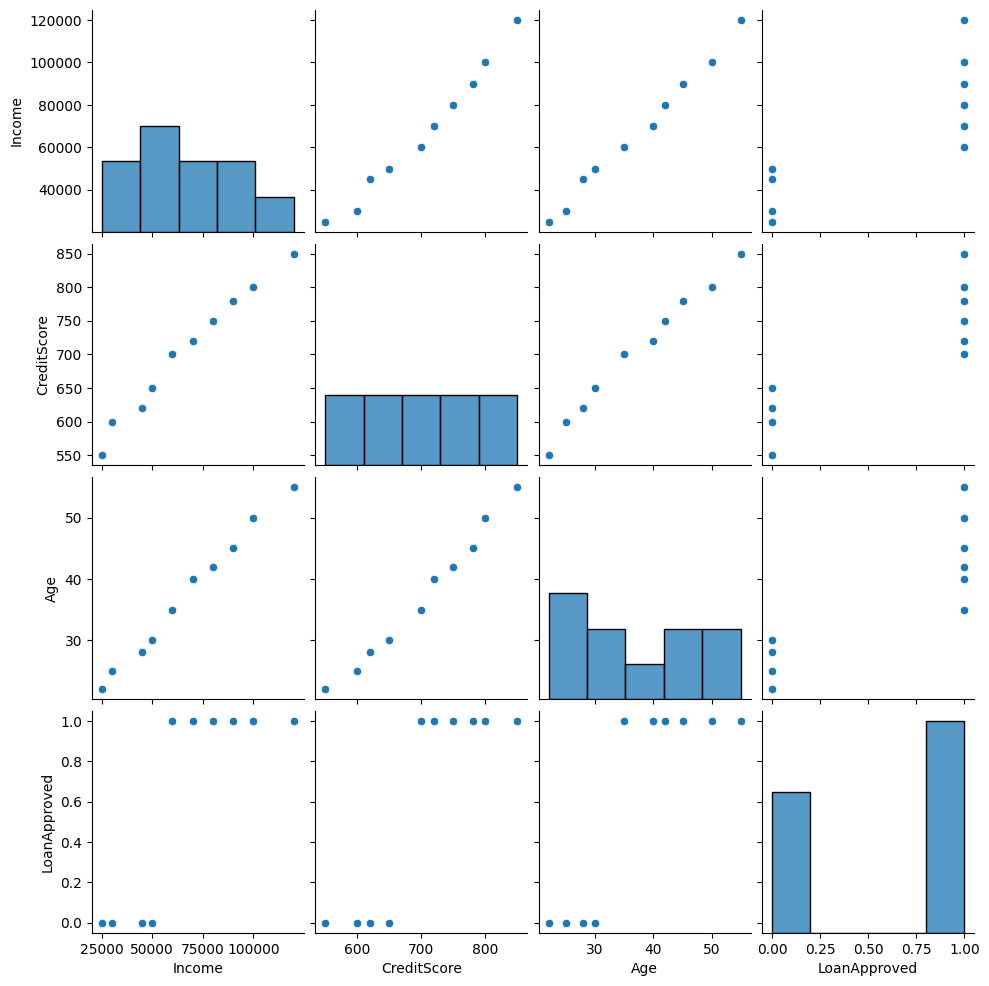

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.pairplot(dataset)
plt.show()

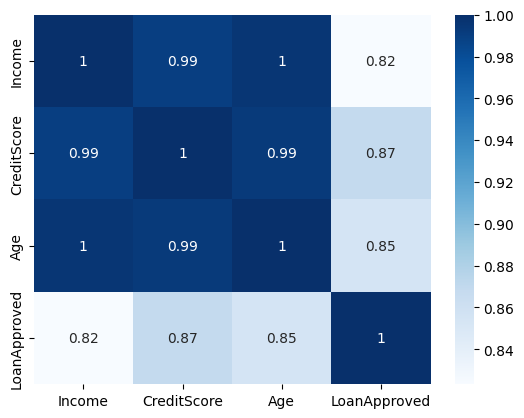

In [7]:
sns.heatmap(dataset.corr(numeric_only=True),
            annot=True,
            cmap="Blues")
plt.show()

In [8]:
X = dataset[["Income","CreditScore","Age"]]
y = dataset["LoanApproved"]

In [9]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [10]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(
    criterion="gini",
    random_state=42
)

model.fit(x_train,y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [11]:
prediction = model.predict(x_test)

In [12]:
new_customer = [[65000,710,32]]

result = model.predict(new_customer)

print(result)

[1]


C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [13]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test,prediction)

print("Accuracy :",accuracy*100)

Accuracy : 100.0


In [14]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test,prediction)

print(cm)

[[1 0]
 [0 1]]


In [15]:
from sklearn.metrics import classification_report

print(classification_report(y_test,prediction))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2



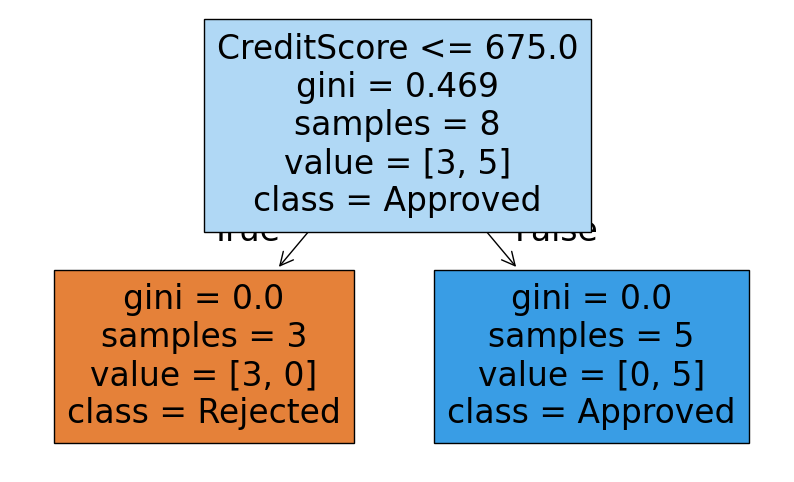

In [16]:
from sklearn.tree import plot_tree

plt.figure(figsize=(10,6))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Rejected","Approved"],
    filled=True
)

plt.show()

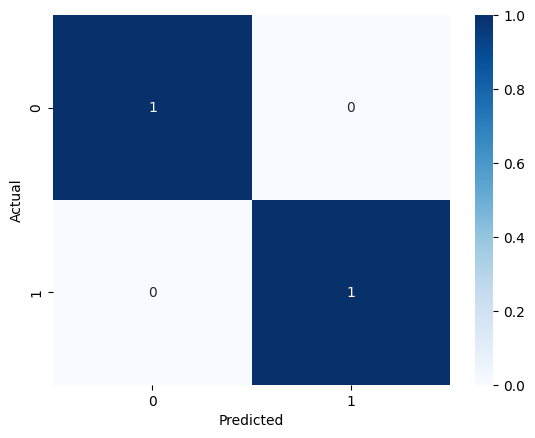

In [17]:
sns.heatmap(
    cm,
    annot=True,
    cmap="Blues",
    fmt="d"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [18]:
importance = pd.DataFrame({
    "Feature":X.columns,
    "Importance":model.feature_importances_
})

importance.sort_values(
    by="Importance",
    ascending=False,
    inplace=True
)

print(importance)

       Feature  Importance
1  CreditScore         1.0
0       Income         0.0
2          Age         0.0


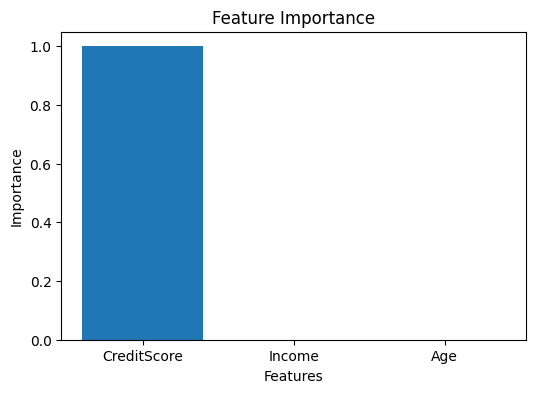

In [19]:
plt.figure(figsize=(6,4))

plt.bar(
    importance["Feature"],
    importance["Importance"]
)

plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")

plt.show()